# Multivariate Calculus & Gradients

从一元导数推广到多元：偏导数、方向导数、梯度向量。核心结论：**梯度是函数上升最快的方向，负梯度是下降最快的方向**——这就是深度学习里每个参数更新方向的来源。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import matplotlib

# 中文字体：避免图上中文显示为方块（macOS 用苹方，Windows 用微软雅黑）
matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False   # 修复负号显示为方块

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 从一元到多元：偏导数


### 1.1 定义：固定其他变量，只对一个变量求导

对 $f(x_1, \dots, x_n)$，**偏导数**就是把其余 $n-1$ 个变量当成常数，对第 $i$ 个变量用一元导数定义：

$$\frac{\partial f}{\partial x_i} = \lim_{h \to 0} \frac{f(x_1, \dots, x_i{+}h, \dots, x_n) - f(x_1, \dots, x_n)}{h}$$

例如 $f(x, y) = x^2 + y^2$：固定 $y$ 对 $x$ 求导得 $\partial f/\partial x = 2x$；固定 $x$ 对 $y$ 求导得 $\partial f/\partial y = 2y$。下面用中心差分数值验证。


In [2]:
def f(x, y):
    return x**2 + y**2

def partial_x(f, x, y, h=1e-6):
    return (f(x + h, y) - f(x - h, y)) / (2 * h)

def partial_y(f, x, y, h=1e-6):
    return (f(x, y + h) - f(x, y - h)) / (2 * h)

x, y = 1.5, -0.5
print(f"∂f/∂x @ ({x}, {y})  数值 = {partial_x(f, x, y):.8f}  解析 = {2*x:.8f}")
print(f"∂f/∂y @ ({x}, {y})  数值 = {partial_y(f, x, y):.8f}  解析 = {2*y:.8f}")


∂f/∂x @ (1.5, -0.5)  数值 = 3.00000000  解析 = 3.00000000
∂f/∂y @ (1.5, -0.5)  数值 = -1.00000000  解析 = -1.00000000


### 1.2 几何意义：切片曲线的切线

偏导数 $\partial f/\partial x$ 是"把 $y$ 固定后得到的 $x$ 方向切片曲线"在该点的切线斜率。下面分别沿 $x$、$y$ 两个方向切一刀，看切片曲线和切线。


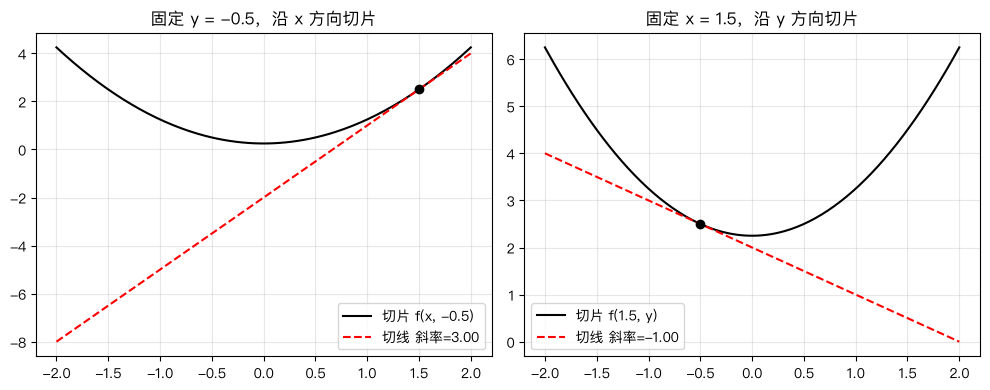

In [3]:
x, y = 1.5, -0.5
xs = np.linspace(-2, 2, 200)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 沿 x 方向切片：固定 y
axes[0].plot(xs, f(xs, y), 'k-', label='切片 f(x, -0.5)')
axes[0].plot(xs, f(x, y) + 2*x*(xs - x), 'r--', label=f'切线 斜率={2*x:.2f}')
axes[0].scatter([x], [f(x, y)], color='black', zorder=5)
axes[0].set_title('固定 y = -0.5，沿 x 方向切片')
axes[0].legend(); axes[0].grid(alpha=0.3)

# 沿 y 方向切片：固定 x
axes[1].plot(xs, f(x, xs), 'k-', label='切片 f(1.5, y)')
axes[1].plot(xs, f(x, y) + 2*y*(xs - y), 'r--', label=f'切线 斜率={2*y:.2f}')
axes[1].scatter([y], [f(x, y)], color='black', zorder=5)
axes[1].set_title('固定 x = 1.5，沿 y 方向切片')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()


## 2. 方向导数：任意方向的变化率


### 2.1 定义

偏导数只回答"沿坐标轴方向变多快"。沿**任意单位方向 $u$** 的变化率叫方向导数：

$$D_u f = \lim_{h \to 0} \frac{f(x + hu) - f(x)}{h}$$

**关键定理**：$D_u f = \nabla f \cdot u$，其中梯度 $\nabla f = (\partial f/\partial x_1, \dots, \partial f/\partial x_n)$。这是多元微积分的一阶泰勒的直接推论：$f(x{+}hu) \approx f(x) + h\,\nabla f \cdot u$。代码验证：


In [4]:
def directional(f, x, y, ux, uy, h=1e-6):
    """方向导数数值：沿单位方向 u 的中心差商"""
    return (f(x + h*ux, y + h*uy) - f(x - h*ux, y - h*uy)) / (2 * h)

x, y = 1.0, 2.0
theta = np.pi / 3          # 60° 方向
ux, uy = np.cos(theta), np.sin(theta)

grad_x, grad_y = 2*x, 2*y  # f = x²+y² 的解析梯度
numeric = directional(f, x, y, ux, uy)
formula = grad_x*ux + grad_y*uy
print(f"D_u f 数值值 = {numeric:.10f}")
print(f"D_u f 公式值 = ∇f·u = {formula:.10f}")


D_u f 数值值 = 4.4641016150
D_u f 公式值 = ∇f·u = 4.4641016151


### 2.2 方向导数随方向变化：余弦曲线

固定一点，把方向 $u$ 绕一圈，$D_u f = \nabla f \cdot u = |\nabla f|\cos\theta$ 是余弦曲线——最大值恰好在梯度方向。


Text(0.5, 1.0, '方向导数 = $|\\nabla f|\\cos\\theta$：最大值出现在梯度方向')

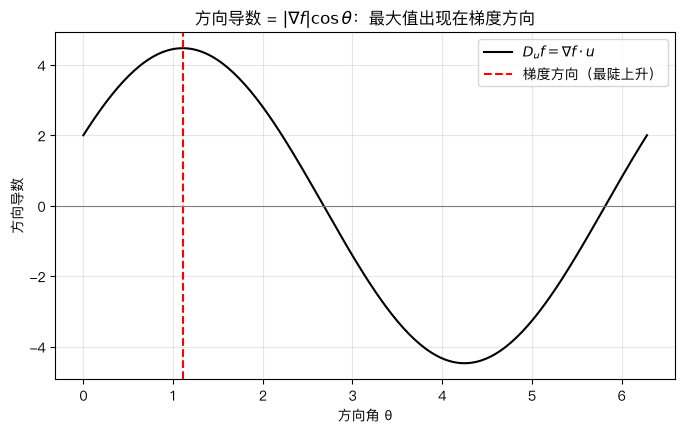

In [5]:
thetas = np.linspace(0, 2*np.pi, 200)
x, y = 1.0, 2.0
grad = np.array([2*x, 2*y])
D = np.array([grad @ [np.cos(t), np.sin(t)] for t in thetas])

plt.figure(figsize=(8, 4.5))
plt.plot(thetas, D, 'k-', label=r'$D_u f = \nabla f\cdot u$')
best = np.arctan2(grad[1], grad[0])
plt.axvline(best, color='red', linestyle='--', label='梯度方向（最陡上升）')
plt.axhline(0, color='gray', linewidth=0.8)
plt.xlabel('方向角 θ'); plt.ylabel('方向导数')
plt.legend(); plt.grid(alpha=0.3)
plt.title(r'方向导数 = $|\nabla f|\cos\theta$：最大值出现在梯度方向')


## 3. 梯度：最陡上升方向


### 3.1 证明

由 $D_u f = \nabla f \cdot u$ 和柯西-施瓦茨不等式：

$$|D_u f| \le |\nabla f|\,|u| = |\nabla f|$$

等号当且仅当 $u$ 与 $\nabla f$ **同向**时成立。所以：

- **梯度方向** = 函数上升最快的方向
- **负梯度方向** = 函数下降最快的方向（深度学习优化的全部理论基础）

### 3.2 等高线与梯度正交

等高线 $f(x,y) = c$ 上取一点，切线方向 $t$ 满足 $df = \nabla f \cdot t = 0$（沿等高线函数值不变），故 $\nabla f \perp t$——梯度处处垂直于等高线。


Text(0.5, 1.0, '梯度场：红色箭头处处垂直于等高线，指向上升方向')

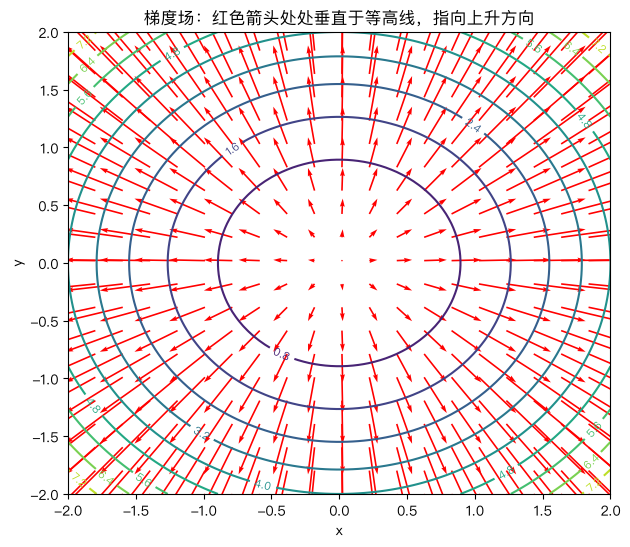

In [6]:
xs = np.linspace(-2, 2, 100)
ys = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(xs, ys)
Z = X**2 + Y**2

plt.figure(figsize=(7, 6))
cs = plt.contour(X, Y, Z, levels=10, cmap='viridis')
plt.clabel(cs, inline=True, fontsize=8)

# 梯度场（每 5 个网格点画一个箭头）
step = 5
plt.quiver(X[::step, ::step], Y[::step, ::step],
           2*X[::step, ::step], 2*Y[::step, ::step],
           color='red', scale=30)

plt.xlabel('x'); plt.ylabel('y')
plt.title('梯度场：红色箭头处处垂直于等高线，指向上升方向')


## 4. 多元链式法则：路径上的全导数


### 4.1 公式

若 $x = x(t),\, y = y(t)$ 沿一条路径运动，则 $f(x(t), y(t))$ 对 $t$ 的**全导数**：

$$\frac{d}{dt} f(x(t), y(t)) = \frac{\partial f}{\partial x}\,x'(t) + \frac{\partial f}{\partial y}\,y'(t) = \nabla f \cdot \big(x'(t), y'(t)\big)$$

即"梯度点乘速度"。若路径沿等高线走，速度垂直于梯度，全导数为 0。


In [7]:
# 沿单位圆运动：x(t)=cos t, y(t)=sin t，f = x²+y² 恒等于 1 → 全导数应为 0
t = 0.8
xt, yt = np.cos(t), np.sin(t)
x_p, y_p = -np.sin(t), np.cos(t)     # 速度向量（单位长度）

numeric = directional(f, xt, yt, x_p, y_p)     # 沿速度方向的方向导数
formula = (2*xt)*x_p + (2*yt)*y_p              # ∇f · 速度
print(f"d/dt f 数值 = {numeric:.2e}")
print(f"d/dt f 公式 = f_x·x' + f_y·y' = {formula:.2e}")
print("沿等高线走 → 函数值不变，再次印证梯度与等高线正交")


d/dt f 数值 = 0.00e+00
d/dt f 公式 = f_x·x' + f_y·y' = 0.00e+00
沿等高线走 → 函数值不变，再次印证梯度与等高线正交


## 5. 用 autograd 算多元梯度


PyTorch 的 `backward()` 对每个 `requires_grad=True` 的输入各给一个梯度分量——它一次就算出了整个梯度向量。第 5 课会揭示它内部就是链式法则。


In [8]:
x = torch.tensor(1.0, dtype=torch.float64, requires_grad=True)
y = torch.tensor(2.0, dtype=torch.float64, requires_grad=True)
z = x**2 + y**2
z.backward()

print(f"autograd: ∂f/∂x = {x.grad.item():.8f}  ∂f/∂y = {y.grad.item():.8f}")
print(f"解析值:   ∂f/∂x = {2*1.0:.8f}  ∂f/∂y = {2*2.0:.8f}")


autograd: ∂f/∂x = 2.00000000  ∂f/∂y = 4.00000000
解析值:   ∂f/∂x = 2.00000000  ∂f/∂y = 4.00000000


## 6. 梯度在深度学习中的意义

一个神经网络的损失函数 $L(w_1, \dots, w_n)$ 是**几千到几十亿维**的多元函数。训练就是反复执行：

$$w \leftarrow w - \eta\,\nabla L(w)$$

- 梯度向量的每个分量，告诉**对应的那一个参数**该往哪个方向调
- 偏导数只回答了"沿坐标轴"的问题，而梯度回答了"哪个方向下降最快"
- 第 3 课会看到：当输出也是向量时，导数升级为 Jacobian 矩阵；梯度只是它的特例

$$\text{一元：斜率 } f' \quad\longrightarrow\quad \text{多元：梯度向量 } \nabla f \quad\longrightarrow\quad \text{向量函数：Jacobian 矩阵 } J$$


## 课后练习


1. **偏导**：用定义（固定其他变量）求 $f(x,y) = x^2 y + \sin(xy)$ 的两个偏导，用中心差分数值验证。
2. **方向导数**：证明方向导数的最大值等于 $|\nabla f|$，且出现在梯度方向（写出完整推导）。
3. **鞍点**：$f(x,y) = x^2 - y^2$，画出等高线和梯度场，观察 $(0,0)$ 处梯度为零但既不是极大也不是极小——这是后面 Hessian（04 课）要解释的现象。
4. **全导数**：$f = e^{xy}$，$r(t) = (\cos t, \sin t)$，求 $d/dt\, f(r(t))$ 在 $t = \pi/4$ 的值（提示：$xy = \cos t\sin t = \tfrac12\sin 2t$）。
5. **autograd**：用 PyTorch 验证 $f(x,y) = e^{xy} + \ln(x+y)$ 在 $(1, 2)$ 的梯度。
